# scOPE end-to-end example

This notebook walks through the complete two-phase scOPE workflow:
1. **Phase 1** — learn latent space from bulk RNA-seq and train mutation classifiers.
2. **Phase 2** — project scRNA-seq into the bulk latent space, infer per-cell mutation probabilities.

**Data notes (BeatAML ID scheme):**
- `labId` / `seq_id`: internal `13-XXXXX` barcodes — RNA and DNA get *different* seq_ids for the same patient, so these cannot be directly joined.
- `dbgap_rnaseq_sample` (`BA*R`): RNA-seq sample IDs used in the harmonized dbGaP expression file.
- `dbgap_dnaseq_sample` (`BA*D`): WES sample IDs used in the dbGaP mutation calls file.
- The clinical file maps `BA*D` → `BA*R` and is required to join mutations to expression.

## 1. Imports & paths

In [1]:
import os

import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt

from scope import BulkPipeline, SingleCellPipeline
from scope.visualization import (
    compute_umap,
    plot_mutation_probabilities,
    plot_scree,
    plot_mutation_heatmap,
)


In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
BEATAML_DIR  = "/Users/ashforda/Desktop/Pathways + Omics/scOPE/scOPE_project_overhaul/scOPE/data/BeatAML"
VANGALEN_DIR = "/Users/ashforda/Desktop/Pathways + Omics/scOPE/scOPE_project_overhaul/scOPE/data/vanGalen_AML_scRNA"
RAW_DIR      = os.path.join(BEATAML_DIR, "publicly_available_and_raw_counts")

# Harmonized dbGaP release — RNA IDs: BA*R, WES IDs: BA*D
bulk_txt   = os.path.join(RAW_DIR, "beataml_waves1to4_norm_exp_dbgap.txt")
mut_path   = os.path.join(RAW_DIR, "beataml_wes_wv1to4_mutations_dbgap.txt")
clin_path  = os.path.join(RAW_DIR, "beataml_wv1to4_clinical.xlsx")
sc_path    = os.path.join(VANGALEN_DIR, "vanGalen_anndata.h5ad")


## 2. Load & prepare bulk RNA-seq

In [3]:
# ── Peek at orientation before loading fully ───────────────────────────────
peek = pd.read_csv(bulk_txt, sep="\t", index_col=0, nrows=3)
print("Raw peek shape (nrows=3):", peek.shape)
print("Row index sample  :", peek.index[:3].tolist())
print("Column name sample:", peek.columns[:3].tolist())


Raw peek shape (nrows=3): (3, 710)
Row index sample  : ['ENSG00000000003', 'ENSG00000000419', 'ENSG00000000457']
Column name sample: ['display_label', 'description', 'biotype']


In [4]:
df_bulk = pd.read_csv(bulk_txt, sep="\t", index_col=0)

# Drop gene metadata columns before transposing
meta_cols = [c for c in df_bulk.columns if not (c.startswith('BA') and c.endswith('R'))]
if meta_cols:
    print(f"Dropping non-sample metadata columns: {meta_cols}")
    df_bulk = df_bulk.drop(columns=meta_cols)

# File is genes × samples — transpose to samples × genes
df_bulk = df_bulk.T

adata_bulk = ad.AnnData(
    X   = df_bulk.values.astype(np.float32),
    obs = pd.DataFrame(index=df_bulk.index),
    var = pd.DataFrame(index=df_bulk.columns),
)

print(f"\nBulk loaded : {adata_bulk.n_obs} samples x {adata_bulk.n_vars} genes")
print(f"Sample IDs  : {adata_bulk.obs_names[:5].tolist()}")
print(f"Gene IDs    : {adata_bulk.var_names[:5].tolist()}")


Dropping non-sample metadata columns: ['display_label', 'description', 'biotype']

Bulk loaded : 707 samples x 22843 genes
Sample IDs  : ['BA2392R', 'BA2611R', 'BA2506R', 'BA2430R', 'BA2448R']
Gene IDs    : ['ENSG00000000003', 'ENSG00000000419', 'ENSG00000000457', 'ENSG00000000460', 'ENSG00000000938']


In [5]:
# ── Remap Ensembl IDs → gene symbols (if needed) ──────────────────────────
if adata_bulk.var_names[0].startswith('ENSG'):
    import mygene
    mg = mygene.MyGeneInfo()
    result = mg.querymany(
        adata_bulk.var_names.tolist(),
        scopes='ensembl.gene', fields='symbol',
        species='human', as_dataframe=True
    )
    id2sym = result['symbol'].dropna().to_dict()
    adata_bulk.var_names = pd.Index([id2sym.get(g, g) for g in adata_bulk.var_names])
    adata_bulk = adata_bulk[:, ~adata_bulk.var_names.str.startswith('ENSG')].copy()
    adata_bulk.var_names_make_unique()
    print(f"After gene remapping : {adata_bulk.n_obs} samples x {adata_bulk.n_vars} genes")
else:
    print(f"Gene IDs already symbols — skipping remap. ({adata_bulk.var_names[0]!r})")

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
3 input query terms found dup hits:	[('ENSG00000175711', 2), ('ENSG00000215156', 2), ('ENSG00000259182', 2)]
1137 input query terms found no hit:	['ENSG00000005955', 'ENSG00000006074', 'ENSG00000006075', 'ENSG00000006114', 'ENSG00000017373', 'ENS


After gene remapping : 707 samples x 19975 genes


/opt/homebrew/Cellar/micromamba/2.5.0_1/envs/scope-dev/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## 3. Build mutation label matrix

The dbGaP mutations file uses `dbgap_sample_id` (`BA*D`, DNA).  
The bulk expression file uses `BA*R` (RNA) IDs.  
The clinical file maps `BA*D` → `BA*R` so we can join them.

In [6]:
# ── Build BA*D → BA*R map from clinical file ───────────────────────────────
clin = pd.read_excel(clin_path)
print("Clinical columns:", clin.columns.tolist())

wes_to_rna = (
    clin[['dbgap_dnaseq_sample', 'dbgap_rnaseq_sample']]
    .dropna()
    .set_index('dbgap_dnaseq_sample')['dbgap_rnaseq_sample']
    .to_dict()
)
print(f"BA*D -> BA*R mappings available: {len(wes_to_rna)}")
print("Sample entry:", next(iter(wes_to_rna.items())))


Clinical columns: ['dbgap_subject_id', 'dbgap_dnaseq_sample', 'dbgap_rnaseq_sample', 'cohort', 'used_manuscript_analyses', 'manuscript_dnaseq', 'manuscript_rnaseq', 'manuscript_inhibitor', 'consensus_sex', 'inferred_sex', 'reportedRace', 'reportedEthnicity', 'inferred_ethnicity', 'centerID', 'CEBPA_Biallelic', 'consensusAMLFusions', 'ageAtDiagnosis', 'isRelapse', 'isDenovo', 'isTransformed', 'specificDxAtAcquisition_MDSMPN', 'nonAML_MDSMPN_specificDxAtAcquisition', 'priorMalignancyNonMyeloid', 'priorMalignancyType', 'cumulativeChemo', 'priorMalignancyRadiationTx', 'priorMDS', 'priorMDSMoreThanTwoMths', 'priorMDSMPN', 'priorMDSMPNMoreThanTwoMths', 'priorMPN', 'priorMPNMoreThanTwoMths', 'dxAtInclusion', 'specificDxAtInclusion', 'ELN2017', 'dxAtSpecimenAcquisition', 'specificDxAtAcquisition', 'ageAtSpecimenAcquisition', 'timeOfSampleCollectionRelativeToInclusion', 'specimenGroups', 'diseaseStageAtSpecimenCollection', 'specimenType', 'rnaSeq', 'exomeSeq', 'totalDrug', 'analysisRnaSeq', 'an

In [7]:
# ── Build binary mutation matrix ───────────────────────────────────────────
AML_GENES = ["FLT3", "NPM1", "DNMT3A", "IDH1", "IDH2", "TET2", "RUNX1", "TP53", "NRAS", "KRAS"]

mut_raw = pd.read_csv(mut_path, sep="\t")
print(f"Mutation file shape    : {mut_raw.shape}")
print(f"dbgap_sample_id sample : {mut_raw['dbgap_sample_id'].iloc[:3].tolist()}")

# Map BA*D -> BA*R
mut_raw['rnaseq_id'] = mut_raw['dbgap_sample_id'].map(wes_to_rna)
n_unmapped = mut_raw['rnaseq_id'].isna().sum()
print(f"Rows unmapped to RNA   : {n_unmapped} / {len(mut_raw)} (expected for WES-only samples)")
mut_raw = mut_raw.dropna(subset=['rnaseq_id'])


Mutation file shape    : (11721, 32)
dbgap_sample_id sample : ['BA2336D', 'BA2336D', 'BA2336D']
Rows unmapped to RNA   : 3636 / 11721 (expected for WES-only samples)


In [8]:
mut_matrix = (
    mut_raw[['rnaseq_id', 'symbol']]
    .drop_duplicates()
    .assign(mutated=1)
    .pivot_table(index='rnaseq_id', columns='symbol', values='mutated', fill_value=0)
)
mut_matrix.columns.name = None
mut_matrix.index.name   = None

genes_present = [g for g in AML_GENES if g in mut_matrix.columns]
genes_missing = [g for g in AML_GENES if g not in mut_matrix.columns]
mutation_labels = mut_matrix[genes_present]

print(f"Mutation matrix : {mutation_labels.shape}")
print(f"Genes found     : {genes_present}")
if genes_missing:
    print(f"Genes missing   : {genes_missing}")
    

Mutation matrix : (637, 10)
Genes found     : ['FLT3', 'NPM1', 'DNMT3A', 'IDH1', 'IDH2', 'TET2', 'RUNX1', 'TP53', 'NRAS', 'KRAS']


In [9]:
# ── Intersect bulk samples with mutation calls ─────────────────────────────
shared = adata_bulk.obs_names.intersection(mutation_labels.index)

print(f"Bulk samples total     : {adata_bulk.n_obs}")
print(f"Samples with mut calls : {len(mutation_labels)}")
print(f"Shared (overlap)       : {len(shared)}")

assert len(shared) > 0, (
    "No overlap between bulk BA*R IDs and mutation-mapped BA*R IDs. "
    "Check that bulk_txt is the dbGaP expression file and that the "
    "clinical file has dbgap_dnaseq_sample / dbgap_rnaseq_sample columns."
)

adata_bulk      = adata_bulk[shared].copy()
mutation_labels = mutation_labels.loc[shared]


Bulk samples total     : 707
Samples with mut calls : 637
Shared (overlap)       : 615


## 4. Load single-cell data & sanity checks

In [10]:
adata_sc = ad.read_h5ad(sc_path)
print(f"SC loaded : {adata_sc.n_obs} cells x {adata_sc.n_vars} genes")


SC loaded : 44823 cells x 27899 genes


In [11]:
# ── Sanity checks ──────────────────────────────────────────────────────────
X = adata_bulk.X
print(f"Bulk  : {adata_bulk.n_obs} samples x {adata_bulk.n_vars} genes")
print(f"SC    : {adata_sc.n_obs} cells x {adata_sc.n_vars} genes")
print(f"Muts  : {mutation_labels.shape}")
print()
print(f"NaN count  : {np.isnan(X).sum()}")
print(f"Inf count  : {np.isinf(X).sum()}")
print(f"Min value  : {np.nanmin(X):.3f}")
print(f"Max value  : {np.nanmax(X):.3f}")
print(f"Neg values : {(X < 0).sum()}  (expected if data is already log-normalised)")
print()
print("Mutation frequencies:")
print(mutation_labels.sum().sort_values(ascending=False))
mutation_labels.head()


Bulk  : 615 samples x 19975 genes
SC    : 44823 cells x 27899 genes
Muts  : (615, 10)

NaN count  : 0
Inf count  : 0
Min value  : -9.122
Max value  : 14.501
Neg values : 2577242  (expected if data is already log-normalised)

Mutation frequencies:
NPM1      141.0
DNMT3A    138.0
NRAS       96.0
TET2       82.0
RUNX1      75.0
IDH2       73.0
FLT3       67.0
TP53       57.0
IDH1       49.0
KRAS       34.0
dtype: float64


,FLT3,NPM1,DNMT3A,IDH1,IDH2,TET2,RUNX1,TP53,NRAS,KRAS
BA2452R,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
BA3379R,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
BA2712R,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
BA2068R,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
BA2236R,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


## 5. Phase 1 — Bulk pipeline

The dbGaP expression file is already log-normalised, so `norm_method='none'` and `log1p=False`.  
`n_components` is capped safely below `n_samples`.

In [12]:
n_components = min(500, adata_bulk.n_obs - 1)
print(f"Using n_components = {n_components}")

bulk_pipe = BulkPipeline(
    norm_method='none',
    log1p=False,
    center=True,
    scale=True,
    decomposition='svd',
    n_components=n_components,
    classifier='logistic',
    classifier_kwargs={
        'C': 0.1,
        'class_weight': 'balanced',
        'max_iter': 10000,
        'solver': 'saga',
    },
)
bulk_pipe.fit(adata_bulk, mutation_labels, cv=5)


18:48:51 | INFO     | scope.pipeline.bulk_pipeline — === BulkPipeline.fit ===
18:48:51 | INFO     | scope.pipeline.bulk_pipeline — Preprocessing bulk data (norm=none, log1p=False).
18:48:51 | INFO     | scope.preprocessing.bulk — BulkNormalizer fitted (method=none).
18:48:51 | INFO     | scope.preprocessing.bulk — BulkScaler fitted (center=True, scale=True).


Using n_components = 500


18:48:51 | INFO     | scope.pipeline.bulk_pipeline — Decomposition: svd (k=500).
18:48:53 | INFO     | scope.decomposition.svd — SVD fitted: 500 components (cumulative EVR=0.979).
18:48:53 | INFO     | scope.pipeline.bulk_pipeline — Training classifiers (logistic).
/opt/homebrew/Cellar/micromamba/2.5.0_1/envs/scope-dev/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
18:48:53 | INFO     | scope.classification.base — Trained classifier for 'FLT3' (n_pos=67 / n_tot=615).
/opt/homebrew/Cellar/micromamba/2.5.0_1/envs/scope-dev/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
18:48:53 | INFO     | scope.classification.base — Trained classifier for 'NPM1' (n_pos=141 / n_tot=615).
/opt/homebrew/Cellar/micromamba/2.5.0_1/envs/scope-dev/lib/

,norm_method,'none'
,log1p,False
,center,True
,scale,True
,decomposition,'svd'
,n_components,500
,decomposition_kwargs,{}
,classifier,'logistic'
,classifier_kwargs,"{'C': 0.1, 'class_weight': 'balanced', 'max_iter': 10000, 'solver': 'saga'}"
,min_positive_frac,0.05
,scale_features,True


In [13]:
# ── CV results summary ─────────────────────────────────────────────────────
summary = (
    bulk_pipe.cv_results_
    .groupby('mutation')[['auroc', 'auprc', 'brier']]
    .agg(['mean', 'std'])
    .round(3)
)

print(summary)


          auroc         auprc         brier       
           mean    std   mean    std   mean    std
mutation                                          
DNMT3A    0.845  0.036  0.658  0.058  0.285  0.026
FLT3      0.635  0.090  0.202  0.053  0.479  0.031
IDH1      0.864  0.053  0.341  0.078  0.498  0.027
IDH2      0.825  0.041  0.415  0.071  0.416  0.012
KRAS      0.696  0.125  0.175  0.116  0.538  0.025
NPM1      0.965  0.020  0.875  0.065  0.137  0.032
NRAS      0.715  0.064  0.299  0.078  0.416  0.030
RUNX1     0.905  0.053  0.598  0.104  0.372  0.026
TET2      0.817  0.061  0.556  0.143  0.380  0.016
TP53      0.939  0.049  0.774  0.140  0.259  0.024


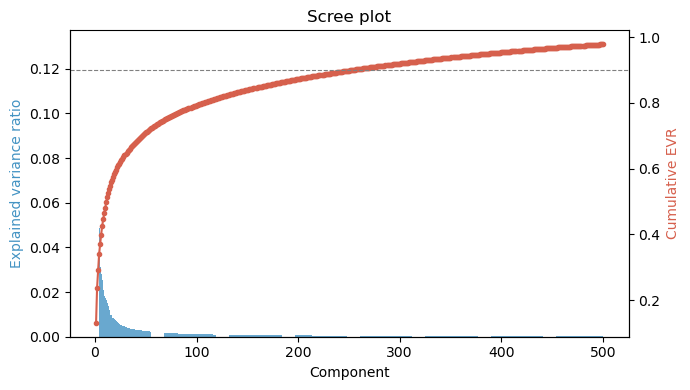

In [14]:
# ── Scree plot ─────────────────────────────────────────────────────────────
scree = bulk_pipe.decomposer_.scree_data()
fig, ax = plot_scree(scree, max_components=n_components)
plt.tight_layout()
plt.show()


## 6. Phase 2 — Single-cell projection

In [15]:
# ── Gene space check ───────────────────────────────────────────────────────
print("Bulk var_names (first 10):", adata_bulk.var_names[:10].tolist())
print("SC   var_names (first 10):", adata_sc.var_names[:10].tolist())

overlap = adata_bulk.var_names.intersection(adata_sc.var_names)

print(f"\nShared genes (bulk intersect SC): {len(overlap)}")


Bulk var_names (first 10): ['TSPAN6', 'DPM1', 'SCYL3', 'FIRRM', 'FGR', 'CFH', 'FUCA2', 'GCLC', 'NFYA', 'STPG1']
SC   var_names (first 10): ['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1', 'A2ML1', 'A2MP1', 'A3GALT2', 'A4GALT', 'A4GNT']

Shared genes (bulk intersect SC): 15498


In [ ]:
# ── Fit & transform single-cell pipeline ──────────────────────────────────
adata_bulk_pp = bulk_pipe.preprocessor_.transform(adata_bulk)

sc_pipe = SingleCellPipeline(
    bulk_pipeline=bulk_pipe,
    alignment_method='z_score_bulk',
    sc_min_counts=200,
    sc_min_genes=200,
)
sc_pipe.fit(adata_bulk_pp, adata_sc)
adata_sc = sc_pipe.transform(adata_sc)

prob_cols = [c for c in adata_sc.obs.columns if c.startswith('mutation_prob_')]

print('Mutation probability columns:', prob_cols)
adata_sc.obs[prob_cols].describe()


18:54:46 | INFO     | scope.pipeline.sc_pipeline — === SingleCellPipeline.fit ===
18:54:46 | INFO     | scope.preprocessing.single_cell — SingleCellPreprocessor fitted.
18:55:28 | INFO     | scope.utils.gene_utils — Gene universe: 15498 shared, 4477 bulk-only, 12401 sc-only
18:55:42 | INFO     | scope.preprocessing.alignment — BulkSCAligner fitted (method=z_score_bulk, n_genes=15498).
18:55:42 | INFO     | scope.pipeline.sc_pipeline — SingleCellPipeline.fit complete.
18:55:42 | INFO     | scope.pipeline.sc_pipeline — === SingleCellPipeline.transform ===
18:56:39 | WARNING  | scope.pipeline.sc_pipeline — 4477 / 19975 bulk genes absent from sc data (will be zero-padded).


## 7. UMAP visualisation

In [ ]:
adata_sc = compute_umap(adata_sc, obsm_key=bulk_pipe.obsm_key_, n_neighbors=15)


In [ ]:
print(adata_sc)
print(adata_sc.obs_names)


In [ ]:
fig = plot_mutation_probabilities(
    adata_sc,
    obsm_key='X_umap',
    ncols=3,
)

fig.savefig('mutation_probability_umap.pdf', bbox_inches='tight')
plt.show()


In [ ]:
# Make more robust ranges for mutation prediction UMAPs
import scanpy as sc
import numpy as np

prob_cols = [c for c in adata_sc.obs.columns if c.startswith('mutation_prob_')]

# Per-gene vmax at 99th percentile so each panel uses its own dynamic range
vmaxes = {c: float(np.percentile(adata_sc.obs[c].values, 99)) for c in prob_cols}

# Floor vmaxes — if 99th pct is basically 0, use 0.1 so the colorbar isn't degenerate
vmaxes = {c: max(v, 0.1) for c, v in vmaxes.items()}

print("Per-gene vmax (99th pct):")
for c, v in vmaxes.items():
    print(f"  {c.replace('mutation_prob_', ''):<8} {v:.3f}")

ncols = 3
nrows = int(np.ceil(len(prob_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = axes.flatten()

for i, col in enumerate(prob_cols):
    gene = col.replace('mutation_prob_', '')
    sc.pl.umap(
        adata_sc,
        color=col,
        ax=axes[i],
        show=False,
        title=f'P({gene} mut)',
        vmin=0.075,
        vmax=vmaxes[col],
        cmap='RdBu_r',
        colorbar_loc='right',
        s=2,  # point size — adjust if too small/large
    )

# Hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
fig.savefig('mutation_probability_umap.pdf', bbox_inches='tight')
plt.show()


In [ ]:
import scanpy as sc

# Parse sample ID from barcode prefix
adata_sc.obs['sample'] = adata_sc.obs_names.str.split('_').str[0]

# Check what orig.ident looks like — may already be the sample label
#print(adata_sc.obs['sample'].value_counts())
#print(adata_sc.obs['orig.ident'].value_counts())


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# By sample
sc.pl.umap(adata_sc, color='sample', ax=axes[0], show=False, title='By sample')

# By cell type (useful reference alongside sample)
sc.pl.umap(adata_sc, color='CellType', ax=axes[1], show=False, title='By cell type')

plt.tight_layout()
plt.savefig('umap_by_sample.pdf', bbox_inches='tight')
plt.show()


## 8. Cluster-level summary (optional)

Run Leiden clustering via scanpy before this cell if desired.

In [ ]:
# import scanpy as sc
# sc.pp.neighbors(adata_sc, use_rep=bulk_pipe.obsm_key_)
# sc.tl.leiden(adata_sc)

if 'leiden' in adata_sc.obs.columns:
    fig, ax = plot_mutation_heatmap(adata_sc, cluster_key='leiden')
    plt.show()
else:
    print("No 'leiden' column found — run scanpy clustering above first.")
    

## 9. Other evaluation of results

In [ ]:
# ── 1. Probability distributions per gene ─────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
for ax, col in zip(axes.flatten(), prob_cols):
    gene = col.replace('mutation_prob_', '')
    vals = adata_sc.obs[col].values
    ax.hist(vals, bins=50, color='steelblue', edgecolor='none')
    ax.axvline(np.percentile(vals, 95), color='red', linestyle='--', lw=1, label='95th pct')
    ax.set_title(gene)
    ax.set_xlabel('P(mut)')
    ax.set_ylabel('# cells')
    ax.legend(fontsize=7)
plt.suptitle('Mutation probability distributions', y=1.02)
plt.tight_layout()
plt.savefig('prob_distributions.pdf', bbox_inches='tight')
plt.show()


In [ ]:
# ── 2. Mean mutation probability per cell type ─────────────────────────────
celltype_means = (
    adata_sc.obs.groupby('CellType')[prob_cols]
    .mean()
    .rename(columns=lambda c: c.replace('mutation_prob_', ''))
    .sort_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(celltype_means.T, aspect='auto', cmap='Reds')
ax.set_xticks(range(len(celltype_means)))
ax.set_xticklabels(celltype_means.index, rotation=45, ha='right')
ax.set_yticks(range(len(celltype_means.columns)))
ax.set_yticklabels(celltype_means.columns)
plt.colorbar(im, ax=ax, label='Mean P(mut)')
ax.set_title('Mean mutation probability by cell type')
plt.tight_layout()
plt.savefig('prob_by_celltype_heatmap.pdf', bbox_inches='tight')
plt.show()

print(celltype_means.round(4))


In [ ]:
# ── 3. Top cells by mutation probability ──────────────────────────────────
# For each gene, what cell types are enriched in the top 5% of cells?
print("Top 5% cell type enrichment per gene:\n")
for col in prob_cols:
    gene = col.replace('mutation_prob_', '')
    threshold = np.percentile(adata_sc.obs[col], 95)
    top_cells = adata_sc.obs[adata_sc.obs[col] >= threshold]
    ct_frac = top_cells['CellType'].value_counts(normalize=True).round(3)
    print(f"{gene} (threshold={threshold:.3f}, n={len(top_cells)}):")
    print(ct_frac.to_string())
    print()
    

In [ ]:
# ── 4. Mutation probability correlation matrix ─────────────────────────────
import seaborn as sns

corr = adata_sc.obs[prob_cols].corr()
corr.index   = corr.index.str.replace('mutation_prob_', '')
corr.columns = corr.columns.str.replace('mutation_prob_', '')

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Mutation probability correlation (per cell)')
plt.tight_layout()
plt.savefig('prob_correlation.pdf', bbox_inches='tight')
plt.show()


In [ ]:
# ── 5. Per-sample mean probability (are some samples driving signal?) ──────
adata_sc.obs['sample'] = adata_sc.obs_names.str.split('_').str[0]

sample_means = (
    adata_sc.obs.groupby('sample')[prob_cols]
    .mean()
    .rename(columns=lambda c: c.replace('mutation_prob_', ''))
)

fig, ax = plt.subplots(figsize=(max(8, len(sample_means) * 0.8), 6))
im = ax.imshow(sample_means.T, aspect='auto', cmap='Reds')
ax.set_xticks(range(len(sample_means)))
ax.set_xticklabels(sample_means.index, rotation=45, ha='right')
ax.set_yticks(range(len(sample_means.columns)))
ax.set_yticklabels(sample_means.columns)
plt.colorbar(im, ax=ax, label='Mean P(mut)')
ax.set_title('Mean mutation probability by sample')
plt.tight_layout()
plt.savefig('prob_by_sample_heatmap.pdf', bbox_inches='tight')
plt.show()


## 10. Patient and mutation status-aware evaluations and visualizations

In [ ]:
# =============================================================================
# CHUNK 0 — Build metadata table from Supplement 8
# =============================================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

AML_GENES = ["FLT3", "NPM1", "DNMT3A", "IDH1", "IDH2", "TET2", "RUNX1", "TP53", "NRAS", "KRAS"]
prob_cols  = [f'mutation_prob_{g}' for g in AML_GENES]

# Load supplement 8
meta = pd.read_excel('/Users/ashforda/Desktop/Pathways + Omics/precepts/VanGalen_paper/supplemental_figures_and_tables/NIHMS1524068-supplement-8.xlsx')

# ── Parse timepoint as integer days ───────────────────────────────────────────
def parse_days(d):
    if pd.isna(d): return np.nan
    m = re.match(r'D(\d+)', str(d))
    return int(m.group(1)) if m else np.nan

meta['days_int'] = meta['Days from diagnosis'].apply(parse_days)

# ── Assign condition ───────────────────────────────────────────────────────────
def assign_condition(row):
    if row['Tissue'] == 'Cell line':  return 'Cell line'
    if row['Sample'].startswith('BM'): return 'Normal'
    if row['days_int'] == 0:           return 'AML Diagnosis'
    if pd.notna(row['days_int']):      return 'AML Post-treatment'
    return 'AML Unknown'

meta['condition'] = meta.apply(assign_condition, axis=1)

# ── Parse known mutations per sample (genes we care about) ────────────────────
def parse_mutations(mut_str):
    """Return set of AML gene symbols detected in RHP Mutations string."""
    if pd.isna(mut_str) or str(mut_str) in ('Not performed', 'None Detected', 'Unknown', 'nan'):
        return set()
    found = set()
    for gene in AML_GENES:
        # Match gene symbol at word boundary, handles FLT3-ITD → FLT3
        if re.search(rf'\b{gene}[\s\-\.]', mut_str) or mut_str.strip().startswith(gene):
            found.add(gene)
    return found

meta['known_mutations'] = meta['RHP Mutations'].apply(parse_mutations)

# Build per-(sample, gene) ground truth lookup
# Key: (sample_id_normalised, gene) → True/False/None (None = not tested)
gt_lookup = {}
for _, row in meta.iterrows():
    sample_key = row['Sample'].replace('-', '.').replace(' ', '_').strip()
    timepoint  = row['days_int']
    mut_str    = str(row['RHP Mutations']) if pd.notna(row['RHP Mutations']) else ''
    not_tested = mut_str in ('Not performed', 'Unknown', 'nan', '')
    for gene in AML_GENES:
        gt_lookup[(sample_key, gene, timepoint)] = (
            None if not_tested else gene in row['known_mutations']
        )

print(meta[['Sample', 'condition', 'days_int', 'known_mutations']].to_string())


In [ ]:
# =============================================================================
# CHUNK 1 — Annotate adata_sc with sample metadata
# =============================================================================

# Parse sample prefix from barcode (e.g. 'AML210A_ACGTGTTT' → 'AML210A')
adata_sc.obs['sample'] = adata_sc.obs_names.str.split('_').str[0]

# Normalise: SC uses 'OCI.AML3', metadata uses 'OCI-AML3'
adata_sc.obs['sample_norm'] = (
    adata_sc.obs['sample']
    .str.replace('.', '-', regex=False)
    .str.replace('_', ' ', regex=False)
)

# Map condition and timepoint from metadata (D0 row for each patient)
# For cells, we use the first (D0) entry for condition labelling
sample_to_condition = (
    meta.sort_values('days_int')             # D0 first
    .drop_duplicates('Sample', keep='first')
    .set_index('Sample')['condition']
    .to_dict()
)
sample_to_days = dict(zip(
    meta['Sample'].str.replace('-', '.').str.replace(' ', '_'),
    meta['days_int'].astype(str)
))

adata_sc.obs['condition'] = (
    adata_sc.obs['sample_norm']
    .map(sample_to_condition)
    .fillna(adata_sc.obs['sample'].map(lambda s: 'Normal' if s.startswith('BM') else 'Unknown'))
)

# Broader group for splitting
def group_label(cond):
    if cond == 'Normal':              return 'Normal BM'
    if cond == 'Cell line':           return 'Cell line'
    if 'AML' in str(cond):            return 'AML patient'
    return 'Unknown'

adata_sc.obs['group'] = adata_sc.obs['condition'].apply(group_label)

print(adata_sc.obs['group'].value_counts())
print(adata_sc.obs['sample'].value_counts())


In [ ]:
# =============================================================================
# CHUNK 2 — UMAP: sample, condition, group, cell type side-by-side
# =============================================================================

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

sc.pl.umap(adata_sc, color='sample',    ax=axes[0], show=False, title='By sample',     legend_loc='right margin', s=2)
sc.pl.umap(adata_sc, color='group',     ax=axes[1], show=False, title='By group',      legend_loc='right margin', s=2)
sc.pl.umap(adata_sc, color='condition', ax=axes[2], show=False, title='By condition',  legend_loc='right margin', s=2)
sc.pl.umap(adata_sc, color='CellType',  ax=axes[3], show=False, title='By cell type',  legend_loc='right margin', s=2)

plt.tight_layout()
plt.savefig('umap_sample_overview.pdf', bbox_inches='tight')
plt.show()


In [ ]:
# =============================================================================
# CHUNK 3 — Split probability distributions: Normal vs AML vs Cell line
# =============================================================================

groups       = ['Normal BM', 'AML patient', 'Cell line']
group_colors = {'Normal BM': '#4878CF', 'AML patient': '#D65F5F', 'Cell line': '#6ACC65'}

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, col in zip(axes.flatten(), prob_cols):
    gene = col.replace('mutation_prob_', '')
    for grp in groups:
        mask = adata_sc.obs['group'] == grp
        vals = adata_sc.obs.loc[mask, col].values
        ax.hist(vals, bins=40, alpha=0.5, density=True,
                color=group_colors[grp], label=grp, edgecolor='none')
    ax.set_title(gene, fontsize=10)
    ax.set_xlabel('P(mut)')
    ax.set_ylabel('Density')

axes[0, 0].legend(fontsize=7)
plt.suptitle('Mutation probability distributions by group', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('prob_dist_by_group.pdf', bbox_inches='tight')
plt.show()


In [ ]:
# =============================================================================
# CHUNK 4 — Box/violin plots: Normal vs AML vs Cell line per gene
# =============================================================================

df_plot = adata_sc.obs[['group'] + prob_cols].copy()
df_long  = df_plot.melt(id_vars='group', var_name='gene', value_name='prob')
df_long['gene'] = df_long['gene'].str.replace('mutation_prob_', '')

fig, ax = plt.subplots(figsize=(16, 5))
sns.violinplot(
    data=df_long, x='gene', y='prob', hue='group',
    order=AML_GENES,
    hue_order=groups,
    palette=group_colors,
    cut=0, inner='quartile', linewidth=0.8, ax=ax
)
ax.set_xlabel('Gene')
ax.set_ylabel('P(mutation)')
ax.set_title('Mutation probabilities by group')
ax.legend(title='Group', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('prob_violin_by_group.pdf', bbox_inches='tight')
plt.show()


In [ ]:
# =============================================================================
# CHUNK 5 — Ground truth concordance
# For samples with known mutations at D0, compare mean predicted prob
# in that sample vs samples where the gene is NOT mutated
# =============================================================================

# Build per-sample ground truth at D0
d0_meta = meta[meta['days_int'] == 0].copy()
d0_meta['sample_norm'] = d0_meta['Sample'].str.replace('-', '.').str.replace(' ', '_')

records = []
for _, row in d0_meta.iterrows():
    sample = row['sample_norm']          # matches SC barcode prefix
    mask   = adata_sc.obs['sample'] == sample
    n_cells = mask.sum()
    if n_cells == 0:
        continue
    for gene in AML_GENES:
        gt = gene in row['known_mutations']
        mean_prob = adata_sc.obs.loc[mask, f'mutation_prob_{gene}'].mean()
        records.append({
            'sample': sample,
            'gene': gene,
            'ground_truth': gt,
            'mean_prob': mean_prob,
            'n_cells': n_cells,
        })

concordance_df = pd.DataFrame(records)

# Print summary table
pivot = concordance_df.pivot_table(
    index='gene', columns='ground_truth', values='mean_prob', aggfunc='mean'
).rename(columns={True: 'mean_prob (mut=True)', False: 'mean_prob (mut=False)'})
pivot['fold_enrichment'] = pivot['mean_prob (mut=True)'] / pivot['mean_prob (mut=False)'].replace(0, np.nan)
print("\nConcordance summary (D0 AML samples):")
print(pivot.round(4))

# Visualise
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, gene in zip(axes.flatten(), AML_GENES):
    sub = concordance_df[concordance_df['gene'] == gene]
    pos = sub[sub['ground_truth']  == True]['mean_prob'].values
    neg = sub[sub['ground_truth'] == False]['mean_prob'].values
    for val, label, color in [(pos, 'Mutated', '#D65F5F'), (neg, 'WT', '#4878CF')]:
        ax.scatter(
            np.random.normal(0 if label == 'Mutated' else 1, 0.05, len(val)),
            val, alpha=0.6, color=color, s=30, label=label
        )
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Mutated', 'WT'])
    ax.set_title(gene, fontsize=10)
    ax.set_ylabel('Mean P(mut) per sample')

axes[0, 0].legend(fontsize=7)
plt.suptitle('Mean predicted probability: mutated vs WT samples (D0)', y=1.02)
plt.tight_layout()
plt.savefig('concordance_d0.pdf', bbox_inches='tight')
plt.show()


In [ ]:
# =============================================================================
# CHUNK 6 — Longitudinal: D0 vs post-treatment within same patient
# =============================================================================

# Patients with multiple timepoints in SC data
longitudinal_patients = (
    meta[meta['Sample'].str.startswith('AML')]
    .groupby('Sample')['days_int']
    .nunique()
)
longitudinal_patients = longitudinal_patients[longitudinal_patients > 1].index.tolist()
print("Patients with longitudinal SC data:", longitudinal_patients)

# Build per-patient per-timepoint mean probabilities
long_records = []
for patient in longitudinal_patients:
    patient_rows = meta[meta['Sample'] == patient].sort_values('days_int')
    for _, row in patient_rows.iterrows():
        sample_key = row['Sample'].replace('-', '.').replace(' ', '_')
        mask = adata_sc.obs['sample'] == sample_key
        if mask.sum() == 0:
            continue
        for gene in AML_GENES:
            long_records.append({
                'patient': patient,
                'days': row['days_int'],
                'gene': gene,
                'mean_prob': adata_sc.obs.loc[mask, f'mutation_prob_{gene}'].mean(),
                'n_cells': mask.sum(),
            })

long_df = pd.DataFrame(long_records)

if len(long_df) > 0:
    patients_in_data = long_df['patient'].unique()
    n_patients = len(patients_in_data)
    fig, axes = plt.subplots(
        n_patients, len(AML_GENES),
        figsize=(len(AML_GENES) * 2, n_patients * 2.5),
        sharey='col'
    )
    if n_patients == 1:
        axes = axes[np.newaxis, :]

    for i, patient in enumerate(patients_in_data):
        sub = long_df[long_df['patient'] == patient].sort_values('days')
        for j, gene in enumerate(AML_GENES):
            gsub = sub[sub['gene'] == gene]
            axes[i, j].plot(gsub['days'], gsub['mean_prob'], 'o-', color='#D65F5F', ms=5)
            axes[i, j].set_ylim(0, None)
            if i == 0:
                axes[i, j].set_title(gene, fontsize=9)
            if j == 0:
                axes[i, j].set_ylabel(patient, fontsize=8, rotation=45, ha='right')
            axes[i, j].set_xlabel('Day', fontsize=7)
            axes[i, j].tick_params(labelsize=6)

    plt.suptitle('Mean mutation probability over treatment course', y=1.01, fontsize=12)
    plt.tight_layout()
    plt.savefig('longitudinal_probs.pdf', bbox_inches='tight')
    plt.show()
else:
    print("No longitudinal samples found in SC data matching metadata.")


In [ ]:
# =============================================================================
# CHUNK 7 — Per-sample mean probability heatmap, annotated by condition
# =============================================================================

sample_means = (
    adata_sc.obs.groupby('sample')[prob_cols]
    .mean()
    .rename(columns=lambda c: c.replace('mutation_prob_', ''))
)

# Annotate condition per sample (use first match from metadata)
sample_meta_map = (
    meta.assign(sample_norm=meta['Sample'].str.replace('-', '.').str.replace(' ', '_'))
    .sort_values('days_int')
    .drop_duplicates('sample_norm', keep='first')
    .set_index('sample_norm')[['condition', 'days_int']]
)
sample_means['condition'] = sample_means.index.map(
    lambda s: sample_meta_map.loc[s, 'condition'] if s in sample_meta_map.index else 'Unknown'
)
sample_means = sample_means.sort_values('condition')

condition_palette = {
    'Normal': '#4878CF',
    'AML Diagnosis': '#D65F5F',
    'AML Post-treatment': '#F5A623',
    'Cell line': '#6ACC65',
    'Unknown': '#AAAAAA',
}
row_colors = sample_means['condition'].map(condition_palette)

plot_data = sample_means.drop(columns='condition')

g = sns.clustermap(
    plot_data,
    row_colors=row_colors,
    col_cluster=False,
    row_cluster=True,
    cmap='Reds',
    figsize=(12, max(6, len(sample_means) * 0.35)),
    xticklabels=True,
    yticklabels=True,
    linewidths=0.3,
    dendrogram_ratio=0.1,
)
# Add condition legend
from matplotlib.patches import Patch
legend_handles = [Patch(color=v, label=k) for k, v in condition_palette.items()]
g.ax_heatmap.legend(
    handles=legend_handles, title='Condition',
    bbox_to_anchor=(1.25, 1), loc='upper left', frameon=True
)
g.fig.suptitle('Mean mutation probability per sample', y=1.01)
plt.savefig('prob_heatmap_per_sample.pdf', bbox_inches='tight')
plt.show()


In [ ]:
# =============================================================================
# CHUNK 8 — UMAP per gene split: Normal BM vs AML Diagnosis vs Post-treatment
# (small multiples — one row per group, one col per gene)
# =============================================================================

groups_ordered = ['Normal BM', 'AML patient (D0)', 'AML patient (post-Tx)', 'Cell line']

# Refine condition labels with timepoint
def fine_condition(row):
    if row['group'] == 'Normal BM':   return 'Normal BM'
    if row['group'] == 'Cell line':   return 'Cell line'
    if row['condition'] == 'AML Diagnosis':     return 'AML patient (D0)'
    if row['condition'] == 'AML Post-treatment': return 'AML patient (post-Tx)'
    return 'AML patient (unknown)'

adata_sc.obs['fine_condition'] = adata_sc.obs.apply(fine_condition, axis=1)

vmaxes = {c: max(float(np.percentile(adata_sc.obs[c].values, 99)), 0.1) for c in prob_cols}

for group_label_str, group_key in [
    ('Normal BM', 'Normal BM'),
    ('AML D0', 'AML patient (D0)'),
    ('Post-treatment', 'AML patient (post-Tx)'),
    ('Cell lines', 'Cell line'),
]:
    sub = adata_sc[adata_sc.obs['fine_condition'] == group_key].copy()
    if sub.n_obs == 0:
        print(f"Skipping {group_label_str} — no cells.")
        continue

    ncols = 5
    nrows = 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
    axes = axes.flatten()

    for i, col in enumerate(prob_cols):
        gene = col.replace('mutation_prob_', '')
        sc.pl.umap(
            sub, color=col, ax=axes[i], show=False,
            title=f'P({gene} mut)',
            vmin=0.0, vmax=vmaxes[col],
            cmap='Reds', colorbar_loc='right', s=3,
        )
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f'Mutation probabilities — {group_label_str} (n={sub.n_obs} cells)', fontsize=13)
    plt.tight_layout()
    fname = f'umap_probs_{group_key.replace(" ", "_").replace("(", "").replace(")", "")}.pdf'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")


## 11. Save outputs

In [ ]:
os.makedirs('models',  exist_ok=True)
os.makedirs('results', exist_ok=True)

bulk_pipe.save('models/bulk_pipeline.pkl')
adata_sc.write_h5ad('results/sc_with_mutation_probs.h5ad')
print("Saved: models/bulk_pipeline.pkl")
print("Saved: results/sc_with_mutation_probs.h5ad")
